<a href="https://colab.research.google.com/github/junitin1000/TestRepoWpi/blob/main/cs548_hw2_q7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#7.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.rcParams['figure.figsize'] = (10, 6)

a)

In [ ]:
# Load dataset
df = pd.read_csv('auto-mpg.csv')

# Rename columns to match assignment naming
df.columns = ['mpg', 'cylinders', 'displacement', 'horsepower',
              'weight', 'acceleration', 'model-year', 'origin', 'car-name']

# Replace '?' with NaN and convert horsepower to numeric
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# Continuous attributes
for col in ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']:
    df[col] = df[col].astype(float)

# Discrete attributes
for col in ['cylinders', 'model-year', 'origin']:
    df[col] = df[col].astype('category')

# String attribute
df['car-name'] = df['car-name'].astype(str)

print('Shape:', df.shape)
print()
print('Data types:')
print(df.dtypes)
print()
print(df.head())

Shape: (398, 9)

Data types:
mpg              float64
cylinders       category
displacement     float64
horsepower       float64
weight           float64
acceleration     float64
model-year      category
origin          category
car-name          object
dtype: object

    mpg cylinders  displacement  horsepower  weight  acceleration model-year  \
0  18.0         8         307.0       130.0  3504.0          12.0         70   
1  15.0         8         350.0       165.0  3693.0          11.5         70   
2  18.0         8         318.0       150.0  3436.0          11.0         70   
3  16.0         8         304.0       150.0  3433.0          12.0         70   
4  17.0         8         302.0       140.0  3449.0          10.5         70   

  origin                   car-name  
0      1  chevrolet chevelle malibu  
1      1          buick skylark 320  
2      1         plymouth satellite  
3      1              amc rebel sst  
4      1                ford torino  


b)

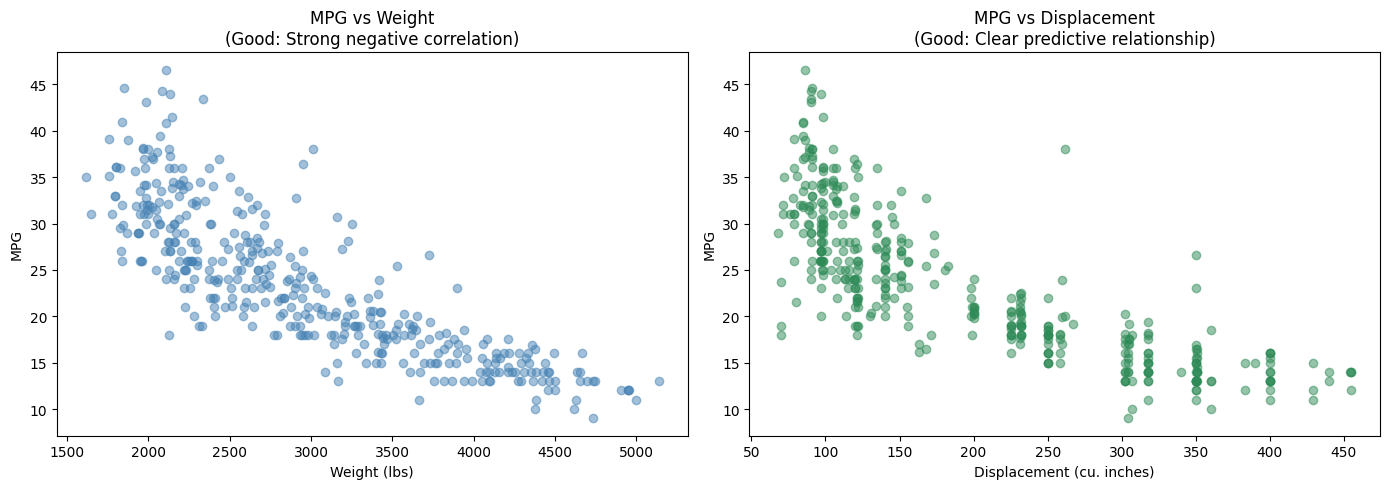

Good Thing 1: Strong, clear correlations between MPG and physical attributes (weight, displacement).
These relationships will be useful for prediction tasks.


In [ ]:
# Good thing # 1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['weight'], df['mpg'], alpha=0.5, color='steelblue')
axes[0].set_xlabel('Weight (lbs)')
axes[0].set_ylabel('MPG')
axes[0].set_title('MPG vs Weight\n(Good: Strong negative correlation)')
axes[1].scatter(df['displacement'], df['mpg'], alpha=0.5, color='seagreen')
axes[1].set_xlabel('Displacement (cu. inches)')
axes[1].set_ylabel('MPG')
axes[1].set_title('MPG vs Displacement\n(Good: Clear predictive relationship)')

plt.tight_layout()
plt.savefig('good_correlations.png', dpi=100)
plt.show()
print('Good Thing 1: Strong, clear correlations between MPG and physical attributes (weight, displacement).')
print('These relationships will be useful for prediction tasks.')

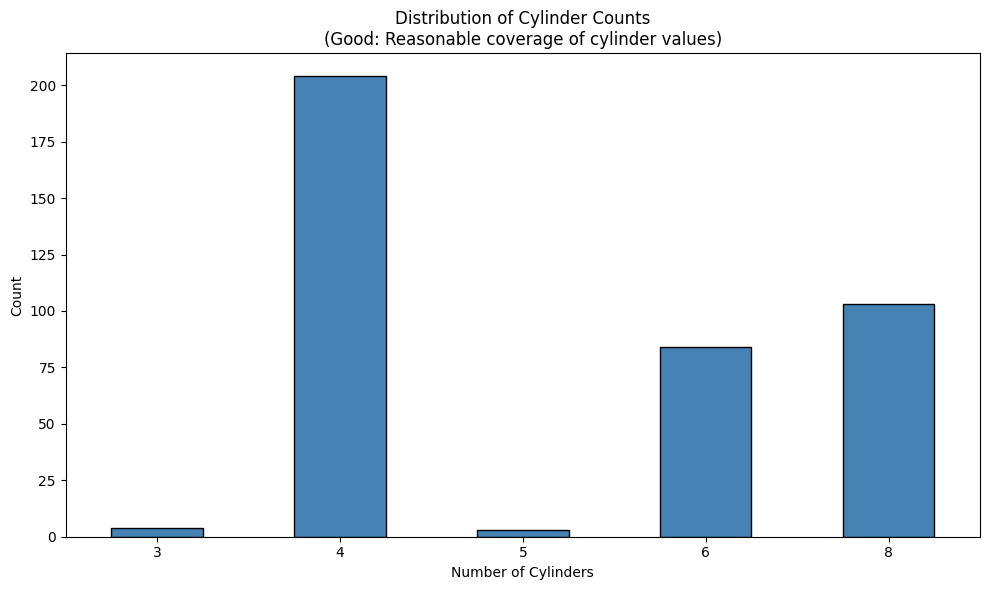

Good Thing 2: The dataset has reasonable coverage of different cylinder counts.
4 cylinder and 8 cylinder cars are well represented, giving the model variety to learn from.


In [ ]:
# Good thing # 2
cyl_counts = df['cylinders'].value_counts().sort_index()
cyl_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribution of Cylinder Counts\n(Good: Reasonable coverage of cylinder values)')
plt.xlabel('Number of Cylinders')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('good_cylinders.png', dpi=100)
plt.show()
print('Good Thing 2: The dataset has reasonable coverage of different cylinder counts.')
print('4 cylinder and 8 cylinder cars are well represented, giving the model variety to learn from.')

In [ ]:
# Bad Thing # 1
print('Bad Thing 1: Missing values in horsepower')
print(f'Number of missing horsepower values: {df["horsepower"].isnull().sum()}')
print(f'% missing: {df["horsepower"].isnull().mean()*100:.1f}%')


Bad Thing 1: Missing values in horsepower
Number of missing horsepower values: 6
% missing: 1.5%


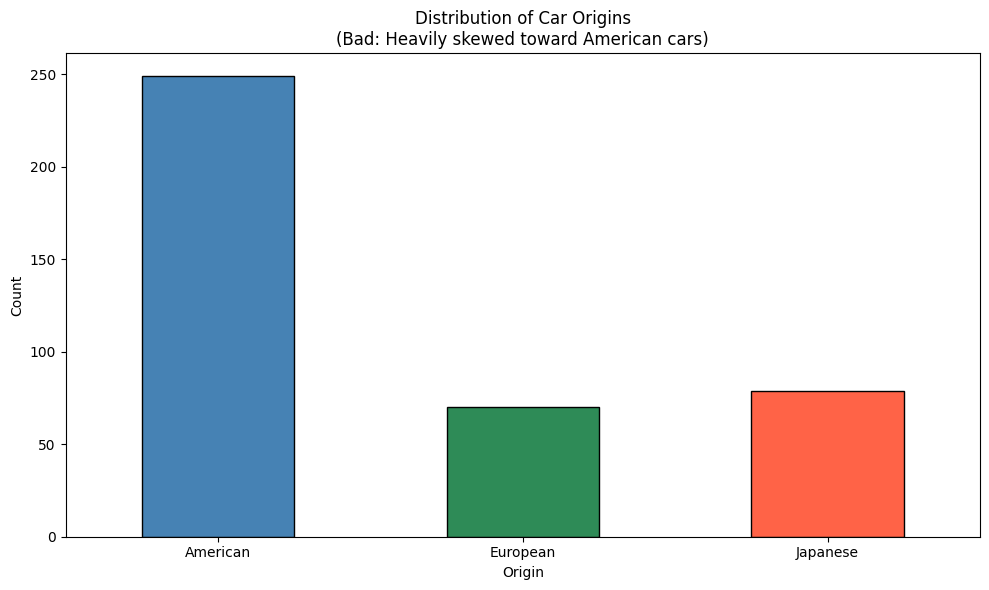


Bad Thing 2: Origin is heavily skewed — most cars are American.
This imbalance could bias models toward American car characteristics.


In [ ]:
# Bad Thing # 2
origin_counts = df['origin'].value_counts().sort_index()
origin_counts.index = ['American', 'European', 'Japanese']
origin_counts.plot(kind='bar', color=['steelblue', 'seagreen', 'tomato'], edgecolor='black')
plt.title('Distribution of Car Origins\n(Bad: Heavily skewed toward American cars)')
plt.xlabel('Origin')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('bad_origin_skew.png', dpi=100)
plt.show()
print()
print('Bad Thing 2: Origin is heavily skewed — most cars are American.')
print('This imbalance could bias models toward American car characteristics.')

c)

In [ ]:
hp = df['horsepower'].dropna()

# Percentiles in increments of 10
percentiles = np.arange(0, 110, 10)
pct_values = np.percentile(hp, percentiles)

print('Horsepower Percentiles (increments of 10)')
for p, v in zip(percentiles, pct_values):
    print(f'  {p}th percentile: {v:.1f}')

print()
print(f'Mean:     {hp.mean():.2f}')
print(f'Median:   {hp.median():.2f}')
print(f'Range:    {hp.max() - hp.min():.2f}  (min={hp.min():.1f}, max={hp.max():.1f})')
print(f'Variance: {hp.var():.2f}')

Horsepower Percentiles (increments of 10)
  0th percentile: 46.0
  10th percentile: 67.0
  20th percentile: 72.0
  30th percentile: 80.0
  40th percentile: 88.0
  50th percentile: 93.5
  60th percentile: 100.0
  70th percentile: 110.0
  80th percentile: 140.0
  90th percentile: 157.7
  100th percentile: 230.0

Mean:     104.47
Median:   93.50
Range:    184.00  (min=46.0, max=230.0)
Variance: 1481.57


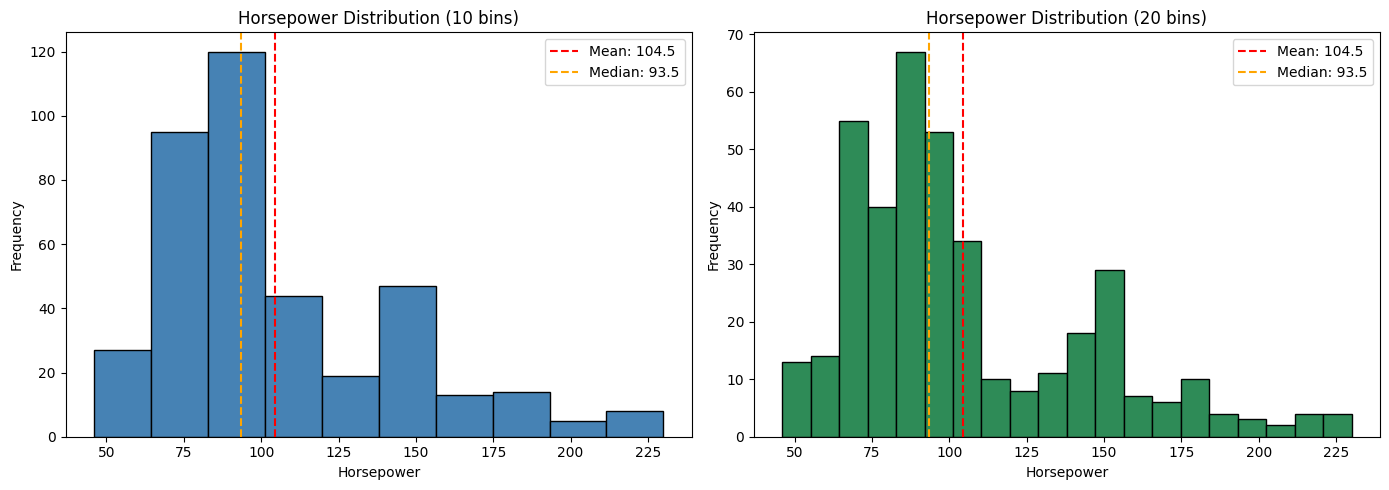

In [ ]:
# horsepower histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(hp, bins=10, color='steelblue', edgecolor='black')
axes[0].set_title('Horsepower Distribution (10 bins)')
axes[0].set_xlabel('Horsepower')
axes[0].set_ylabel('Frequency')
axes[0].axvline(hp.mean(), color='red', linestyle='--', label=f'Mean: {hp.mean():.1f}')
axes[0].axvline(hp.median(), color='orange', linestyle='--', label=f'Median: {hp.median():.1f}')
axes[0].legend()

axes[1].hist(hp, bins=20, color='seagreen', edgecolor='black')
axes[1].set_title('Horsepower Distribution (20 bins)')
axes[1].set_xlabel('Horsepower')
axes[1].set_ylabel('Frequency')
axes[1].axvline(hp.mean(), color='red', linestyle='--', label=f'Mean: {hp.mean():.1f}')
axes[1].axvline(hp.median(), color='orange', linestyle='--', label=f'Median: {hp.median():.1f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('horsepower_histogram.png', dpi=100)
plt.show()

d)

Covariance Matrix
                  mpg  cylinders  displacement  horsepower     weight  \
mpg             60.92     -10.35       -657.59     -233.86   -5517.44   
cylinders      -10.35       2.91        169.72       55.35    1300.42   
displacement  -657.59     169.72      10950.37     3614.03   82929.10   
horsepower    -233.86      55.35       3614.03     1481.57   28265.62   
weight       -5517.44    1300.42      82929.10    28265.62  721484.71   
acceleration     9.12      -2.38       -156.99      -73.19    -976.82   
model-year      16.69      -2.17       -142.57      -59.04    -967.23   
origin           3.55      -0.78        -51.80      -14.11    -400.27   

              acceleration  model-year  origin  
mpg                   9.12       16.69    3.55  
cylinders            -2.38       -2.17   -0.78  
displacement       -156.99     -142.57  -51.80  
horsepower          -73.19      -59.04  -14.11  
weight             -976.82     -967.23 -400.27  
acceleration          7.61    

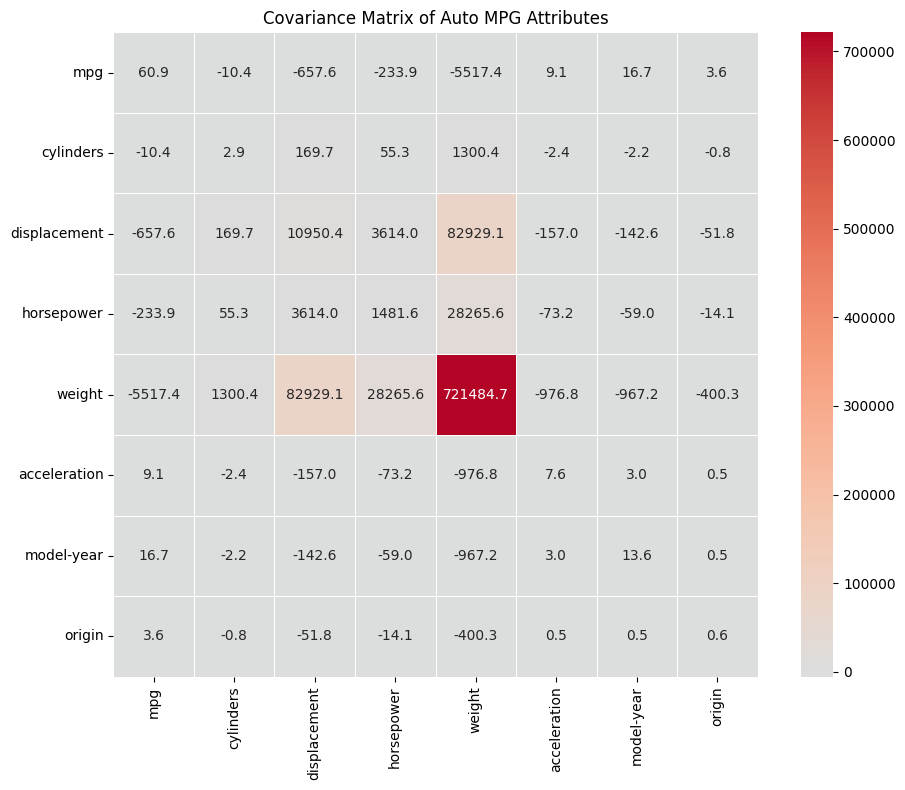

In [ ]:
# Use all attributes except car name, treating discrete as continuous
# Drop rows with missing horsepower values first
df_numeric = df.drop(columns=['car-name']).copy()
for col in ['cylinders', 'model-year', 'origin']:
    df_numeric[col] = df_numeric[col].astype(float)
df_numeric = df_numeric.dropna()

# Covariance matrix
cov_matrix = df_numeric.cov()
print('Covariance Matrix')
print(cov_matrix.round(2))
# Visualize covariance matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cov_matrix, annot=True, fmt='.1f', cmap='coolwarm', center=0, linewidths=0.5, square=True)
plt.title('Covariance Matrix of Auto MPG Attributes')
plt.tight_layout()
plt.savefig('covariance_matrix.png', dpi=100)
plt.show()

Correlation Matrix
                mpg  cylinders  displacement  horsepower  weight  \
mpg           1.000     -0.778        -0.805      -0.778  -0.832   
cylinders    -0.778      1.000         0.951       0.843   0.898   
displacement -0.805      0.951         1.000       0.897   0.933   
horsepower   -0.778      0.843         0.897       1.000   0.865   
weight       -0.832      0.898         0.933       0.865   1.000   
acceleration  0.423     -0.505        -0.544      -0.689  -0.417   
model-year    0.581     -0.346        -0.370      -0.416  -0.309   
origin        0.565     -0.569        -0.615      -0.455  -0.585   

              acceleration  model-year  origin  
mpg                  0.423       0.581   0.565  
cylinders           -0.505      -0.346  -0.569  
displacement        -0.544      -0.370  -0.615  
horsepower          -0.689      -0.416  -0.455  
weight              -0.417      -0.309  -0.585  
acceleration         1.000       0.290   0.213  
model-year           0.29

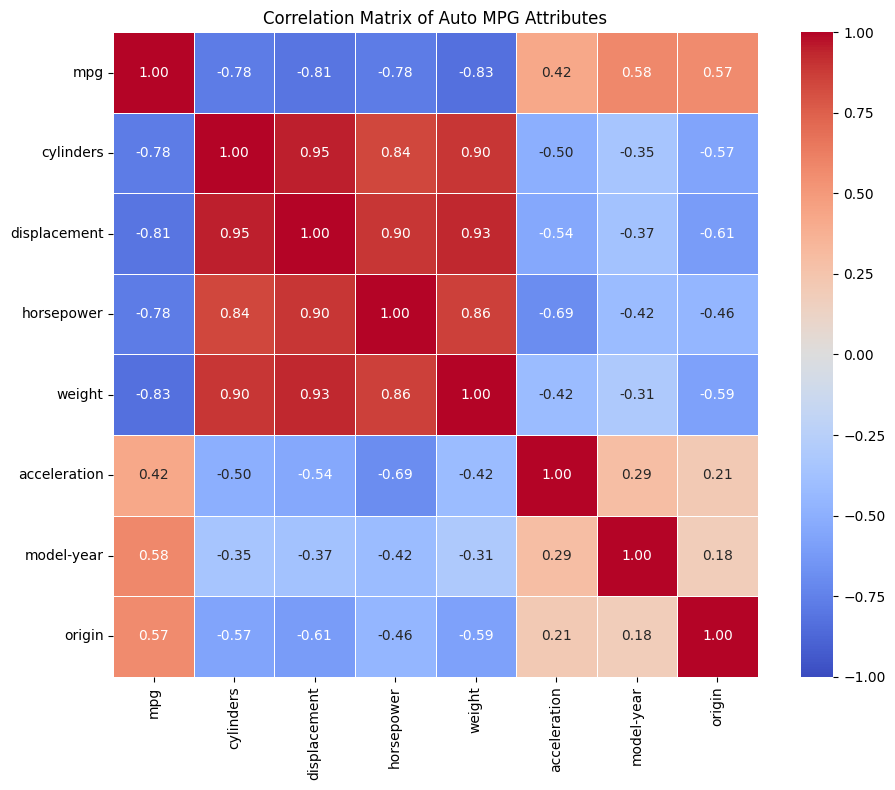

In [ ]:
# Correlation matrix
corr_matrix = df_numeric.corr()
print('Correlation Matrix')
print(corr_matrix.round(3))
# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, linewidths=0.5, square=True)
plt.title('Correlation Matrix of Auto MPG Attributes')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=100)
plt.show()

e)

In [ ]:
print('Highly Correlated Pairs |r| > 0.85')
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.85:
            print(f'  {corr_matrix.columns[i]} <-> {corr_matrix.columns[j]}: r = {r:.3f}')

print()
print('Recommendation: Remove "displacement" and "weight".')
print('Reasoning:')
print('* Displacement is very highly correlated with cylinders (r~0.95) and weight (r~0.93).')
print('It adds little unique information beyond what cylinders and weight already capture.')
print('* Weight is highly correlated with displacement (r~0.93) and horsepower (r~0.86).')
print('Removing it reduces redundancy while keeping horsepower, which has a more')
print('direct mechanical relationship with mpg.')

Highly Correlated Pairs |r| > 0.85
  cylinders <-> displacement: r = 0.951
  cylinders <-> weight: r = 0.898
  displacement <-> horsepower: r = 0.897
  displacement <-> weight: r = 0.933
  horsepower <-> weight: r = 0.865

Recommendation: Remove "displacement" and "weight".
Reasoning:
* Displacement is very highly correlated with cylinders (r~0.95) and weight (r~0.93).
It adds little unique information beyond what cylinders and weight already capture.
* Weight is highly correlated with displacement (r~0.93) and horsepower (r~0.86).
Removing it reduces redundancy while keeping horsepower, which has a more
direct mechanical relationship with mpg.


f)

In [ ]:
# Standardize  data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

print(f'Original dataset dimensions: {df_numeric.shape[1]} attributes, {df_numeric.shape[0]} instances')
print(f'Attributes: {list(df_numeric.columns)}')

Original dataset dimensions: 8 attributes, 392 instances
Attributes: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model-year', 'origin']


In [ ]:
# Apply PCA
pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print('Variance Explained by Each Component:')
for i, (ev, cv) in enumerate(zip(explained_variance, cumulative_variance)):
    print(f'  PC{i+1}: {ev*100:.2f}%  (cumulative: {cv*100:.2f}%)')
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f'\nComponents needed to explain 95% of variance: {n_95}')

Variance Explained by Each Component:
  PC1: 67.20%  (cumulative: 67.20%)
  PC2: 11.80%  (cumulative: 78.99%)
  PC3: 10.15%  (cumulative: 89.14%)
  PC4: 6.08%  (cumulative: 95.22%)
  PC5: 2.29%  (cumulative: 97.50%)
  PC6: 1.43%  (cumulative: 98.93%)
  PC7: 0.67%  (cumulative: 99.60%)
  PC8: 0.40%  (cumulative: 100.00%)

Components needed to explain 95% of variance: 4


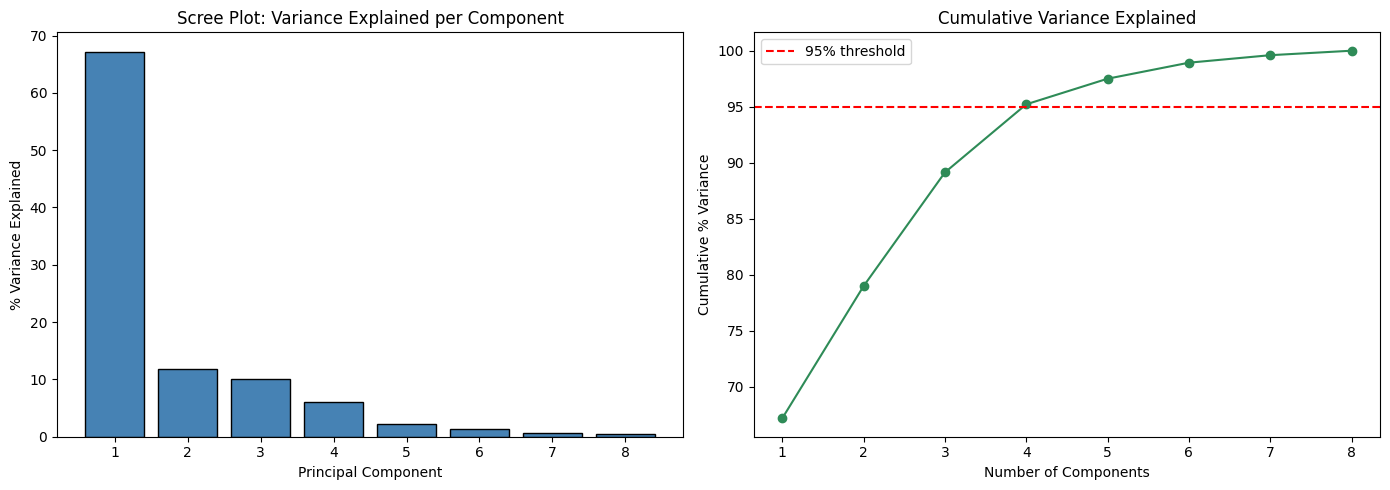

In [ ]:
# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(explained_variance)+1), explained_variance*100,
            color='steelblue', edgecolor='black')
axes[0].set_title('Scree Plot: Variance Explained per Component')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('% Variance Explained')
axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance*100,
             marker='o', color='seagreen')
axes[1].axhline(95, color='red', linestyle='--', label='95% threshold')
axes[1].set_title('Cumulative Variance Explained')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative % Variance')
axes[1].legend()

plt.tight_layout()
plt.savefig('pca_scree.png', dpi=100)
plt.show()

First Principal Component (PC1) Linear Combination

  mpg: -0.3859
  cylinders: 0.4024
  displacement: 0.4164
  horsepower: 0.4018
  weight: 0.4016
  acceleration: -0.2647
  model-year: -0.2139
  origin: -0.2779

PC1 = -0.3859 * mpg + +0.4024 * cylinders + +0.4164 * displacement + +0.4018 * horsepower + +0.4016 * weight + -0.2647 * acceleration + -0.2139 * model-year + -0.2779 * origin

Interpretation:
PC1 captures the primary axis of variation in the dataset.
Attributes with large absolute loadings contribute most to PC1.


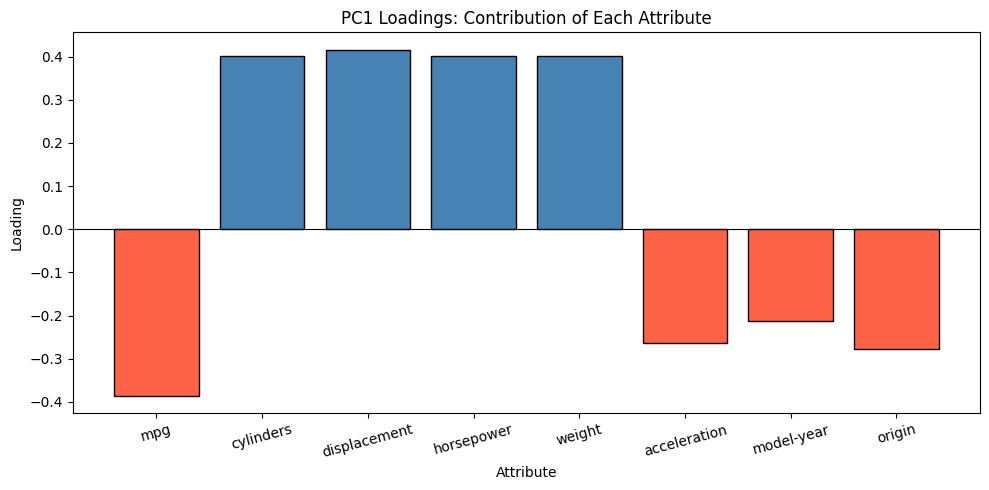

In [ ]:
# First principal component — linear combination
pc1_loadings = pca.components_[0]
print('First Principal Component (PC1) Linear Combination')
print()
terms = []
for attr, loading in zip(df_numeric.columns, pc1_loadings):
    sign = '+' if loading >= 0 else '-'
    terms.append(f'{loading:+.4f} * {attr}')
    print(f'  {attr}: {loading:.4f}')

print()
print('PC1 =', ' + '.join(terms))
print()
print('Interpretation:')
print('PC1 captures the primary axis of variation in the dataset.')
print('Attributes with large absolute loadings contribute most to PC1.')

# Loadings bar chart
plt.figure(figsize=(10, 5))
colors = ['steelblue' if x >= 0 else 'tomato' for x in pc1_loadings]
plt.bar(df_numeric.columns, pc1_loadings, color=colors, edgecolor='black')
plt.title('PC1 Loadings: Contribution of Each Attribute')
plt.xlabel('Attribute')
plt.ylabel('Loading')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('pc1_loadings.png', dpi=100)
plt.show()

Observations from PCA:

1. Original dimensions: 8
2. PC1 alone explains 67.2% of total variance.
3. First 4 components explain at least 95% of total variance.
This means we can reduce from 8 to 4 dimensions
while retaining 95% of the information.

4. PC1 loadings: displacement, cylinders, weight, and horsepower tend to
load together (all related to engine size/power), while mpg and model-year
load in the opposite direction — capturing the general trend that heavier,
more powerful older cars have lower mpg.

5. The high variance explained by just 1-2 components confirms the strong
multicollinearity we observed in the correlation matrix